In [1]:
import torch
from torch import nn

torch.__version__

'2.10.0.dev20251124+cu128'

In [2]:
import torch
import torchvision

torch.__version__, torchvision.__version__

('2.10.0.dev20251124+cu128', '0.25.0.dev20251124+cu128')

In [3]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pneumonia_dataset"

if image_path.is_dir():
    print(f"{image_path} directory already exists... skipping download")
else:
    print(f"{image_path} does not exist, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

data\pneumonia_dataset directory already exists... skipping download


In [5]:
## 2. Becoming one with the data (data preparation and data exploration)
import os
def walk_through_dir(dir_path):
    """Walks through dir_path returning its contents"""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dir_path}'.")

In [6]:
walk_through_dir(image_path)

There are 3 directories and 0 images in 'data\pneumonia_dataset'.
There are 2 directories and 0 images in 'data\pneumonia_dataset'.
There are 0 directories and 234 images in 'data\pneumonia_dataset'.
There are 0 directories and 390 images in 'data\pneumonia_dataset'.
There are 2 directories and 0 images in 'data\pneumonia_dataset'.
There are 0 directories and 1082 images in 'data\pneumonia_dataset'.
There are 0 directories and 3110 images in 'data\pneumonia_dataset'.
There are 2 directories and 0 images in 'data\pneumonia_dataset'.
There are 0 directories and 267 images in 'data\pneumonia_dataset'.
There are 0 directories and 773 images in 'data\pneumonia_dataset'.


In [7]:
train_dir = image_path / "train"
val_dir = image_path / "val"
test_dir = image_path / "test"

train_dir, test_dir, val_dir

(WindowsPath('data/pneumonia_dataset/train'),
 WindowsPath('data/pneumonia_dataset/test'),
 WindowsPath('data/pneumonia_dataset/val'))

In [8]:
from pathlib import Path
import random
from PIL import Image

dataset_path = Path("data/pneumonia_dataset")

# random.seed(42)

image_path_list = list(dataset_path.glob("*/*/*.jpeg"))

print(f"Toplam bulunan görüntü sayısı: {len(image_path_list)}")

if len(image_path_list) == 0:
    print("HATA: Hiç görüntü bulunamadı! Yolu kontrol edin.")
else:
    random_image_path = random.choice(image_path_list)
    
    image_class = random_image_path.parent.name
    
    split = random_image_path.parent.parent.name
    
    img = Image.open(random_image_path)
    
    print(f"\nRastgele görüntü yolu: {random_image_path}")
    print(f"Split: {split}")
    print(f"Sınıf: {image_class}")
    print(f"Boyut: {img.width} x {img.height}")
    print(f"Mod: {img.mode}") # Gri tonlamalı (L)

    img.show()

Toplam bulunan görüntü sayısı: 5856

Rastgele görüntü yolu: data\pneumonia_dataset\test\opacity\person100_bacteria_478.jpeg
Split: test
Sınıf: opacity
Boyut: 1128 x 624
Mod: L


In [9]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Görüntü boyutlandırma
    transforms.Grayscale(num_output_channels=1), # tek kanallı gri tonlama
    transforms.RandomHorizontalFlip(), # yatay çevir
    transforms.RandomRotation(10), # rastgele döndür
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [10]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(root=train_dir, # etiketleme
                                     transform=train_transforms)

val_dataset = datasets.ImageFolder(root=val_dir,
                                     transform=val_test_transforms)

test_dataset = datasets.ImageFolder(root=test_dir,
                                     transform=val_test_transforms)

In [11]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = 0 # verilerin ram a taşınma hızı

torch.manual_seed(42)

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS)

val_dataloader = DataLoader(dataset=val_dataset,
                            batch_size=BATCH_SIZE,
                            shuffle=False,
                            num_workers=NUM_WORKERS)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=NUM_WORKERS)

In [ ]:
# # model_0 (kendi modelim)

# import torch
# from torch import nn
# import torch.nn.functional as F

# class PneumoniaCNN(nn.Module):
#     def __init__(self):
#         super().__init__()

#         # Birinci evrişimli blok
#         self.conv_block1 = nn.Sequential(
#             nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(num_features=32),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )
        
#         # İkinci evrişimli blok
#         self.conv_block2 = nn.Sequential(
#             nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(num_features=64),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )
        
#         # Üçüncü evrişimli blok
#         self.conv_block3 = nn.Sequential(
#             nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(num_features=128),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )
        
#         # Flatten layer ( çok boyutlu veri -> tek boyutlu bir vektör )
#         self.flatten = nn.Flatten()
        
#         # Sınıflandırma için tam bağlantılı (fully connected) katmanlar
#         self.fc1 = nn.Linear(in_features=128 * 28 * 28, out_features=512)
#         self.dropout1 = nn.Dropout(0.5)
#         self.fc2 = nn.Linear(in_features=512, out_features=128)
#         self.dropout2 = nn.Dropout(0.5)
#         self.fc3 = nn.Linear(in_features=128, out_features=2)

#     def forward(self, x):
#         # Girdiyi evrişimli bloklardan geçirme
#         x = self.conv_block1(x)
#         x = self.conv_block2(x)
#         x = self.conv_block3(x)
        
#         # Öznitelikleri (features) düzleştirme
#         x = self.flatten(x)
        
#         # Tam bağlantılı katmanlar
#         x = F.relu(self.fc1(x))
#         x = self.dropout1(x)
#         x = F.relu(self.fc2(x))
#         x = self.dropout2(x)
#         logits = self.fc3(x)
        
#         # Sonuç skorlarını (logits) alıyoruz
#         return logits

In [ ]:
# # model_1 - https://www.kaggle.com/code/himel1122/final-project-computer-vison

# import torch
# from torch import nn
# import torch.nn.functional as F

# class PneumoniaCNN(nn.Module):
#     def __init__(self, num_classes=2):
#         super().__init__()
        
#         # Conv Block 1: 32 filters
#         self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
#         self.bn1 = nn.BatchNorm2d(32)
#         self.pool1 = nn.MaxPool2d(2)
        
#         # Conv Block 2: 64 filters
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
#         self.bn2 = nn.BatchNorm2d(64)
#         self.pool2 = nn.MaxPool2d(2)
#         self.dropout2 = nn.Dropout2d(0.10)
        
#         # Conv Block 3: 128 filters
#         self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
#         self.bn3 = nn.BatchNorm2d(128)
#         self.pool3 = nn.MaxPool2d(2)
#         self.dropout3 = nn.Dropout2d(0.15)
        
#         # Conv Block 4: 256 filters
#         self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
#         self.bn4 = nn.BatchNorm2d(256)
#         self.pool4 = nn.MaxPool2d(2)
#         self.dropout4 = nn.Dropout2d(0.20)
        
#         # Conv Block 5: 512 filters
#         self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
#         self.bn5 = nn.BatchNorm2d(512)
#         self.pool5 = nn.MaxPool2d(2)
#         self.dropout5 = nn.Dropout2d(0.25)
        
#         # Global Average Pooling (Flatten yerine)
#         self.global_pool = nn.AdaptiveAvgPool2d(1)
        
#         # Fully Connected Layers
#         self.fc1 = nn.Linear(512, 256)
#         self.bn_fc1 = nn.BatchNorm1d(256)
#         self.dropout_fc1 = nn.Dropout(0.40)
        
#         self.fc2 = nn.Linear(256, 128)
#         self.dropout_fc2 = nn.Dropout(0.30)
        
#         self.fc3 = nn.Linear(128, num_classes)
        
#     def forward(self, x):
#         # Conv Block 1
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = self.pool1(x)
        
#         # Conv Block 2
#         x = F.relu(self.bn2(self.conv2(x)))
#         x = self.pool2(x)
#         x = self.dropout2(x)
        
#         # Conv Block 3
#         x = F.relu(self.bn3(self.conv3(x)))
#         x = self.pool3(x)
#         x = self.dropout3(x)
        
#         # Conv Block 4
#         x = F.relu(self.bn4(self.conv4(x)))
#         x = self.pool4(x)
#         x = self.dropout4(x)
        
#         # Conv Block 5
#         x = F.relu(self.bn5(self.conv5(x)))
#         x = self.pool5(x)
#         x = self.dropout5(x)
        
#         # Global Average Pooling
#         x = self.global_pool(x)
#         x = x.view(x.size(0), -1)  # Flatten: (batch, 512, 1, 1) -> (batch, 512)
        
#         # FC Layers
#         x = F.relu(self.bn_fc1(self.fc1(x)))
#         x = self.dropout_fc1(x)
        
#         x = F.relu(self.fc2(x))
#         x = self.dropout_fc2(x)
        
#         logits = self.fc3(x)
        
#         return logits

In [ ]:
# # model_2 - https://www.kaggle.com/code/akbarprdna/pneumonia-detection-from-chest-x-ray-using-cnn

# import torch
# from torch import nn
# import torch.nn.functional as F

# class PneumoniaCNN(nn.Module):
#     def __init__(self, num_classes=2):
#         super().__init__()
        
#         # Conv Block 1
#         self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
#         self.bn1 = nn.BatchNorm2d(32)
#         self.pool1 = nn.MaxPool2d(2)
        
#         # Conv Block 2
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
#         self.bn2 = nn.BatchNorm2d(64)
#         self.pool2 = nn.MaxPool2d(2)
#         self.dropout2 = nn.Dropout2d(0.1)  # Conv'a dropout ekledik
        
#         # Conv Block 3
#         self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
#         self.bn3 = nn.BatchNorm2d(128)
#         self.pool3 = nn.MaxPool2d(2)
#         self.dropout3 = nn.Dropout2d(0.15)
        
#         # Conv Block 4
#         self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
#         self.bn4 = nn.BatchNorm2d(256)
#         self.pool4 = nn.MaxPool2d(2)
#         self.dropout4 = nn.Dropout2d(0.2)
        
#         # Global Average Pooling (KEY IMPROVEMENT)
#         self.global_pool = nn.AdaptiveAvgPool2d(1)
        
#         # FC Layers with L2 regularization (PyTorch'ta weight_decay ile)
#         self.fc1 = nn.Linear(256, 256)
#         self.bn_fc1 = nn.BatchNorm1d(256)
#         self.dropout_fc1 = nn.Dropout(0.5)
        
#         self.fc2 = nn.Linear(256, 128)
#         self.dropout_fc2 = nn.Dropout(0.3)
        
#         self.fc3 = nn.Linear(128, num_classes)
        
#     def forward(self, x):
#         # Conv Blocks
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = self.pool1(x)
        
#         x = F.relu(self.bn2(self.conv2(x)))
#         x = self.pool2(x)
#         x = self.dropout2(x)
        
#         x = F.relu(self.bn3(self.conv3(x)))
#         x = self.pool3(x)
#         x = self.dropout3(x)
        
#         x = F.relu(self.bn4(self.conv4(x)))
#         x = self.pool4(x)
#         x = self.dropout4(x)
        
#         # Global Average Pooling
#         x = self.global_pool(x)
#         x = x.view(x.size(0), -1)  # (batch, 256, 1, 1) -> (batch, 256)
        
#         # FC Layers
#         x = F.relu(self.bn_fc1(self.fc1(x)))
#         x = self.dropout_fc1(x)
        
#         x = F.relu(self.fc2(x))
#         x = self.dropout_fc2(x)
        
#         logits = self.fc3(x)
        
#         return logits

In [ ]:
# # model_3 - https://www.kaggle.com/code/rajasreerajamohanan/pneumonia-detection


# import torch
# from torch import nn
# import torch.nn.functional as F

# class PneumoniaCNN(nn.Module):
#     def __init__(self, img_width=224, img_height=224, num_classes=2):
#         super().__init__()
        
#         # Block-1 (Giriş: 1 kanal - grayscale)
#         self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=0)
#         self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         # Block-2
#         self.conv2_1 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=0)
#         self.pool2_1 = nn.MaxPool2d(kernel_size=2, stride=2)
#         self.conv2_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=0)
#         self.pool2_2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         # Block-3
#         self.conv3_1 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0)
#         self.pool3_1 = nn.MaxPool2d(kernel_size=2, stride=2)
#         self.conv3_2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=0)
#         self.pool3_2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         # Boyut hesaplama
#         with torch.no_grad():
#             dummy_input = torch.zeros(1, 1, img_height, img_width)  # 1 kanal
#             x = self.pool1(F.relu(self.conv1(dummy_input)))
#             x = self.pool2_1(F.relu(self.conv2_1(x)))
#             x = self.pool2_2(F.relu(self.conv2_2(x)))
#             x = self.pool3_1(F.relu(self.conv3_1(x)))
#             x = self.pool3_2(F.relu(self.conv3_2(x)))
#             flattened_size = x.view(1, -1).shape[1]
        
#         self.fc1 = nn.Linear(flattened_size, 128)
#         self.fc2 = nn.Linear(128, 64)
#         self.fc3 = nn.Linear(64, num_classes)
        
#     def forward(self, x):
#         # Block-1
#         x = F.relu(self.conv1(x))
#         x = self.pool1(x)
        
#         # Block-2
#         x = F.relu(self.conv2_1(x))
#         x = self.pool2_1(x)
#         x = F.relu(self.conv2_2(x))
#         x = self.pool2_2(x)
        
#         # Block-3
#         x = F.relu(self.conv3_1(x))
#         x = self.pool3_1(x)
#         x = F.relu(self.conv3_2(x))
#         x = self.pool3_2(x)
        
#         # Flatten
#         x = x.view(x.size(0), -1)
        
#         # FC
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         logits = self.fc3(x)
        
#         return logits

In [ ]:
# # model_4 - https://www.kaggle.com/code/abcdabcddsvgsgdsgf/nexpp

# import torch
# from torch import nn
# import torch.nn.functional as F

# class PneumoniaCNN(nn.Module):
#     def __init__(self, num_classes=2):
#         super().__init__()
        
#         # Conv Layer 1 (Giriş: 1 kanal - grayscale)
#         self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=0)
#         self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         # Conv Layer 2
#         self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0)
#         self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         # Conv Layer 3
#         self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=0)
#         self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         # Boyut hesapla
#         with torch.no_grad():
#             dummy_input = torch.zeros(1, 1, 224, 224)  # 1 kanal
#             x = self.pool1(F.relu(self.conv1(dummy_input)))
#             x = self.pool2(F.relu(self.conv2(x)))
#             x = self.pool3(F.relu(self.conv3(x)))
#             flattened_size = x.view(1, -1).shape[1]
        
#         self.fc1 = nn.Linear(flattened_size, 512)
#         self.dropout = nn.Dropout(0.5)
#         self.fc2 = nn.Linear(512, num_classes)
        
#     def forward(self, x):
#         x = F.relu(self.conv1(x))
#         x = self.pool1(x)
#         x = F.relu(self.conv2(x))
#         x = self.pool2(x)
#         x = F.relu(self.conv3(x))
#         x = self.pool3(x)
#         x = x.view(x.size(0), -1)
#         x = F.relu(self.fc1(x))
#         x = self.dropout(x)
#         logits = self.fc2(x)
#         return logits

In [ ]:
# # model_5 - https://www.kaggle.com/code/martinmauerer/pneumonia-xai


# import torch
# from torch import nn
# import torch.nn.functional as F

# class PneumoniaCNN(nn.Module):
#     def __init__(self, num_classes=2):
#         super().__init__()
        
#         # Block 1 (Giriş: 1 kanal - grayscale)
#         self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=2, stride=2, padding=0)
#         self.bn1 = nn.BatchNorm2d(32)
        
#         self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=2, stride=2, padding=1)
#         self.bn2 = nn.BatchNorm2d(64)
        
#         self.pool1 = nn.MaxPool2d(kernel_size=3, stride=3)
        
#         # Block 2
#         self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
#         self.bn3 = nn.BatchNorm2d(128)
        
#         self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1)
#         self.bn4 = nn.BatchNorm2d(128)
        
#         self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
#         self.bn5 = nn.BatchNorm2d(256)
        
#         # Block 3
#         self.conv6 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
#         self.bn6 = nn.BatchNorm2d(512)
        
#         self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         # Block 4
#         self.conv7 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
#         self.bn7 = nn.BatchNorm2d(512)
        
#         self.conv8 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
#         self.bn8 = nn.BatchNorm2d(512)
        
#         self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         # Block 5
#         self.conv9 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
#         self.bn9 = nn.BatchNorm2d(512)
        
#         self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         # Boyut hesapla (1 kanal için)
#         with torch.no_grad():
#             dummy_input = torch.zeros(1, 1, 224, 224)  # 1 kanal
#             x = F.relu(self.bn1(self.conv1(dummy_input)))
#             x = F.relu(self.bn2(self.conv2(x)))
#             x = self.pool1(x)
#             x = F.relu(self.bn3(self.conv3(x)))
#             x = F.relu(self.bn4(self.conv4(x)))
#             x = F.relu(self.bn5(self.conv5(x)))
#             x = F.relu(self.bn6(self.conv6(x)))
#             x = self.pool2(x)
#             x = F.relu(self.bn7(self.conv7(x)))
#             x = F.relu(self.bn8(self.conv8(x)))
#             x = self.pool3(x)
#             x = F.relu(self.bn9(self.conv9(x)))
#             x = self.pool4(x)
#             flattened_size = x.view(1, -1).shape[1]
        
#         # FC Layers
#         self.fc1 = nn.Linear(flattened_size, 1024)
#         self.dropout1 = nn.Dropout(0.5)
#         self.fc2 = nn.Linear(1024, 1024)
#         self.dropout2 = nn.Dropout(0.5)
#         self.fc3 = nn.Linear(1024, num_classes)
        
#     def forward(self, x):
#         # Block 1
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = F.relu(self.bn2(self.conv2(x)))
#         x = self.pool1(x)
        
#         # Block 2
#         x = F.relu(self.bn3(self.conv3(x)))
#         x = F.relu(self.bn4(self.conv4(x)))
#         x = F.relu(self.bn5(self.conv5(x)))
        
#         # Block 3
#         x = F.relu(self.bn6(self.conv6(x)))
#         x = self.pool2(x)
        
#         # Block 4
#         x = F.relu(self.bn7(self.conv7(x)))
#         x = F.relu(self.bn8(self.conv8(x)))
#         x = self.pool3(x)
        
#         # Block 5
#         x = F.relu(self.bn9(self.conv9(x)))
#         x = self.pool4(x)
        
#         # Flatten
#         x = x.view(x.size(0), -1)
        
#         # FC
#         x = F.relu(self.fc1(x))
#         x = self.dropout1(x)
#         x = F.relu(self.fc2(x))
#         x = self.dropout2(x)
#         logits = self.fc3(x)
        
#         return logits

In [18]:
# Create train_step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.dataloader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device = device):
    # Put the model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch , (X, y) in enumerate(dataloader):
        # Send data to the target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X) # output model logits

        # 2. Calsulate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # 6. Calculate accuracy metric
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [19]:
def val_step(model: torch.nn.Module,
             dataloader: torch.utils.data.dataloader,
             loss_fn = torch.nn.Module,
             device = device):
    # Put the model eval mode
    model.eval()
    
    # Setup test loss and val accuracy values
    val_loss, val_acc = 0, 0

    # Turn on inference mode
    with torch.inference_mode():
        for batch , (X, y) in enumerate(dataloader):
            # Loop through DataLoader batches
            X, y = X.to(device), y.to(device)
    
            # 1. Forward pass
            val_pred_logits = model(X)
    
            # 2. Calculate the loss
            loss = loss_fn(val_pred_logits, y)
            val_loss += loss.item()
    
            # 3. Calculate the accuracy
            val_pred_labels = val_pred_logits.argmax(dim=1)
            val_acc += (val_pred_labels == y).sum().item() / len(y)

    # Adjust metrics to get average loss and accuracy per batch
    val_loss = val_loss / len(dataloader)
    val_acc = val_acc / len(dataloader)
    return val_loss, val_acc

In [20]:
from tqdm.auto import tqdm

# 1. Create a train function that tkaes in vasious model param + opt + dataload + loss func
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.dataloader,
          val_dataloader: torch.utils.data.dataloader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int = 5, 
          device = device):
    # 2. Create empty result dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "val_loss": [],
               "val_acc": []}
    
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        
        val_loss, val_acc = val_step(model=model,
                                     dataloader=val_dataloader,
                                     loss_fn=loss_fn,
                                     device=device)
        
        # 4. Print out what's happening
        print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}% | Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}%")

        # 5. Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [21]:
import torch

from pathlib import Path

def save_model(model: torch.nn.Module,
               target_dir: str,
               model_name: str):
    
    target_dir_path = Path(target_dir)
    target_dir_path.mkdir(parents=True,
                        exist_ok=True)

    assert model_name.endswith(".pth") or model_name.endswith(".pt"), "model_name should end with '.pt' or '.pth'"
    model_save_path = target_dir_path / model_name

    print(f"[INFO] Saving model to: {model_save_path}")
    torch.save(obj=model.state_dict(),
             f=model_save_path)

In [22]:
from timeit import default_timer as timer

torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 10

# Sıfırdan yeni model
model = PneumoniaCNN().to(device)

# Manuel ağırlık
class_weights = torch.tensor([4.0, 0.5]).to(device)
print(f"Sınıf ağırlıkları: {class_weights}")

# Ağırlıklı loss
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0001)

start_time = timer()

model_results = train(model=model,
                      train_dataloader=train_dataloader,
                      val_dataloader=val_dataloader,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=NUM_EPOCHS,
                      device=device)

end_time = timer()
print(f"Total training time: {end_time - start_time:.3f} seconds")

save_model(model=model,
           target_dir="model",
           model_name="model.pth")

Sınıf ağırlıkları: tensor([4.0000, 0.5000], device='cuda:0')


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 0.2095 | Train acc: 0.8552% | Val loss: 0.4881 | Val acc: 0.8097%
Epoch: 1 | Train loss: 0.1233 | Train acc: 0.9277% | Val loss: 0.2549 | Val acc: 0.9015%
Epoch: 2 | Train loss: 0.1070 | Train acc: 0.9349% | Val loss: 0.3027 | Val acc: 0.8750%
Epoch: 3 | Train loss: 0.0967 | Train acc: 0.9454% | Val loss: 0.5031 | Val acc: 0.8144%
Epoch: 4 | Train loss: 0.0940 | Train acc: 0.9475% | Val loss: 0.1740 | Val acc: 0.9337%
Epoch: 5 | Train loss: 0.0668 | Train acc: 0.9611% | Val loss: 0.1802 | Val acc: 0.9403%
Epoch: 6 | Train loss: 0.0633 | Train acc: 0.9594% | Val loss: 0.2158 | Val acc: 0.9280%
Epoch: 7 | Train loss: 0.0594 | Train acc: 0.9616% | Val loss: 0.1413 | Val acc: 0.9536%
Epoch: 8 | Train loss: 0.0639 | Train acc: 0.9599% | Val loss: 0.1668 | Val acc: 0.9366%
Epoch: 9 | Train loss: 0.0589 | Train acc: 0.9649% | Val loss: 0.3691 | Val acc: 0.9479%
Total training time: 491.454 seconds
[INFO] Saving model to: model\model.pth


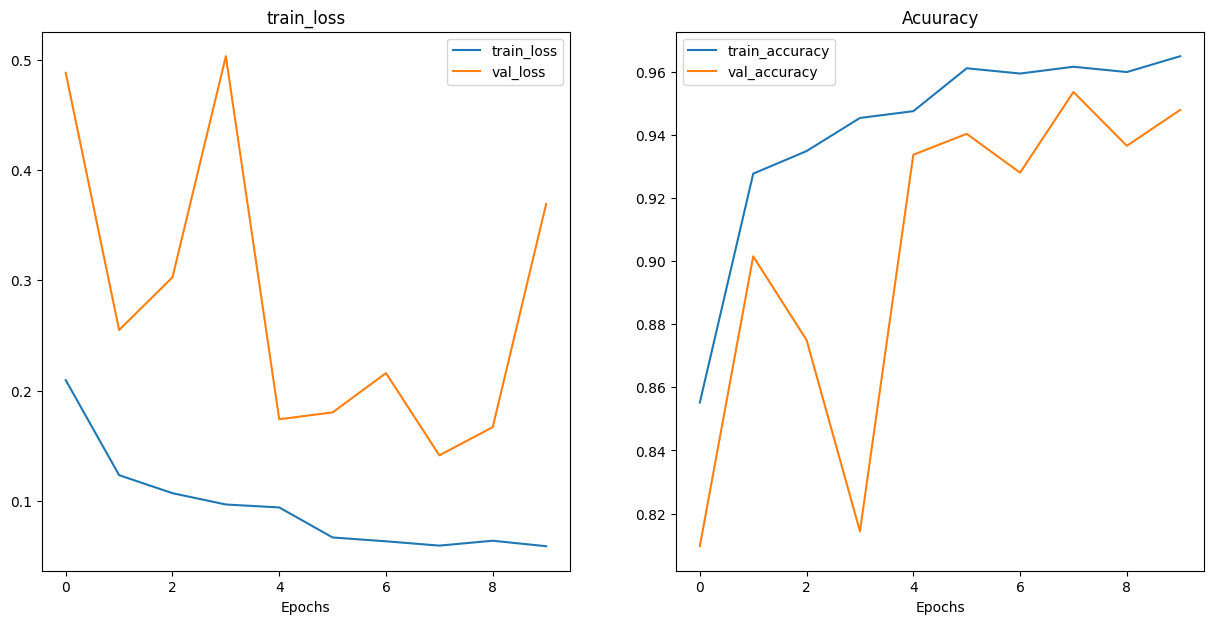

In [23]:
import matplotlib.pyplot as plt
from typing import Dict, List

def plot_train_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary."""
    # Get the train_loss values of the results dictionary(training and test)
    train_loss = results["train_loss"]
    val_train_loss = results["val_loss"]

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results["train_acc"]
    val_accuracy = results["val_acc"]

    # Figure out how many epochs there were
    epochs = range(len(results["train_loss"]))

    # Setup a plot
    plt.figure(figsize=(15,7))

    # Plot the train_loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, val_train_loss, label="val_loss")
    plt.title("train_loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot the accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("Acuuracy")
    plt.xlabel("Epochs")
    plt.legend();

plot_train_loss_curves(model_results)

In [24]:
def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            logits = model(images)

            # En büyük logit hangi sınıf? (argmax)
            preds = torch.argmax(logits, dim=1)

            # Doğruları say
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy, correct, total

acc, correct, total = evaluate_accuracy(model, test_dataloader, device)
print(f"Doğru Tahmin: {correct}/{total}")
print(f"Accuracy: {acc*100:.2f}%")

Doğru Tahmin: 445/624
Accuracy: 71.31%


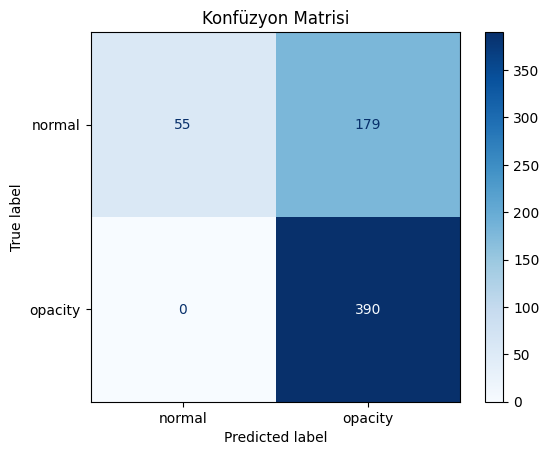

              precision    recall  f1-score   support

      normal       1.00      0.24      0.38       234
     opacity       0.69      1.00      0.81       390

    accuracy                           0.71       624
   macro avg       0.84      0.62      0.60       624
weighted avg       0.80      0.71      0.65       624



In [25]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def get_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

# Tahminleri topla
y_pred, y_true = get_predictions(model, test_dataloader, device)

# Konfüzyon matrisi
class_names = test_dataloader.dataset.classes  # ["NORMAL", "PNEUMONIA"] gibi
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Konfüzyon Matrisi")
plt.show()

# precision, recall, f1-score
print(classification_report(y_true, y_pred, target_names=class_names))

In [26]:
print(loss_fn)  # CrossEntropyLoss(weight=tensor([...]))  olmalı

CrossEntropyLoss()
